In [1]:
import numpy as np
import pandas as pd
import math,copy
import matplotlib.pyplot as plt

In [2]:
import numpy as np

X= np.array([1, 2, 3, 4, 5, 6, 7, 8])
y=np.array([3.5, 3.2, 10.5, 13.9, 27.2, 33.1, 51.5, 60.8])

In [3]:
def normalize(X):
    mu=np.mean(X,axis=0)
    sigma=np.std(X,axis=0)
    X_norm=(X-mu)/sigma
    return X_norm,mu,sigma

In [4]:
X_s=normalize(X)[0]
np.ptp(X_s)

np.float64(3.0550504633038935)

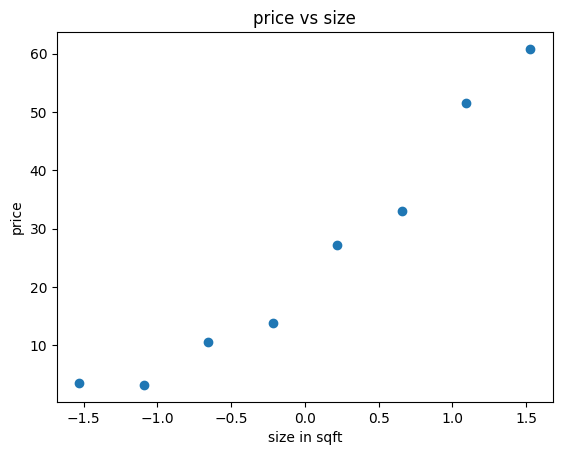

In [5]:
plt.scatter(X_s,y)
plt.title('price vs size')
plt.xlabel('size in sqft')
plt.ylabel('price')
plt.show()

In [6]:
X = X.astype(np.float64)

X_f = np.column_stack([X**i for i in range(1, 8)])

In [7]:
def compute_cost(X,y,w,b):
    m=X.shape[0]
    cost=0

    for i in range(m):
        fwb_i=np.dot(X[i],w)+b
        cost=cost+(fwb_i-y[i])**2

    cost=cost/(2*m)

    return cost
        
    

In [8]:
def compute_gradient(X,y,w,b):
    m,n=X.shape
    dj_dw=np.zeros(n)
    dj_db=0

    for i in range(m):
        fwb_i=np.dot(X[i],w)+b
        err=fwb_i-y[i]
        for j in range(n):
            dj_dw[j]=dj_dw[j]+err*X[i,j]
        dj_db=dj_db+err

    dj_dw=dj_dw/m
    dj_db=dj_db/m



    return dj_db,dj_dw
        

  
    

In [9]:
def gradient_descent(X,y,w_in,b_in,cost_function,gradient_function,aplpha,iterations):

    w=copy.deepcopy(w_in)
    b=b_in
    J_history=[]
    for i in range(iterations):
        dj_db,dj_dw=gradient_function(X,y,w,b)

        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        J_history.append(cost_function(X,y,w,b,))


        if i%math.ceil(iterations/10)==0:
            print(f"Iteration {i:4d} cost:{J_history[-1]:8.2f}")

    return J_history,w,b

In [10]:
w_in=np.zeros(X_f.shape[1])

b_in=0
X_fn=normalize(X_f)[0]
alpha=0.2
iterations=4000
J_history,w,b=gradient_descent(X_fn,y,w_in,b_in,compute_cost,compute_gradient,alpha,iterations)
print(f'Paramters:w:{w},b:{b}')

Iteration    0 cost:  240.69
Iteration  400 cost:    1.98
Iteration  800 cost:    1.86
Iteration 1200 cost:    1.84
Iteration 1600 cost:    1.84
Iteration 2000 cost:    1.84
Iteration 2400 cost:    1.84
Iteration 2800 cost:    1.84
Iteration 3200 cost:    1.84
Iteration 3600 cost:    1.84
Paramters:w:[ 0.42709134 10.05009496  9.45463296  6.62534696  2.92836902 -1.85912493
 -7.89516685],b:25.462499999999995


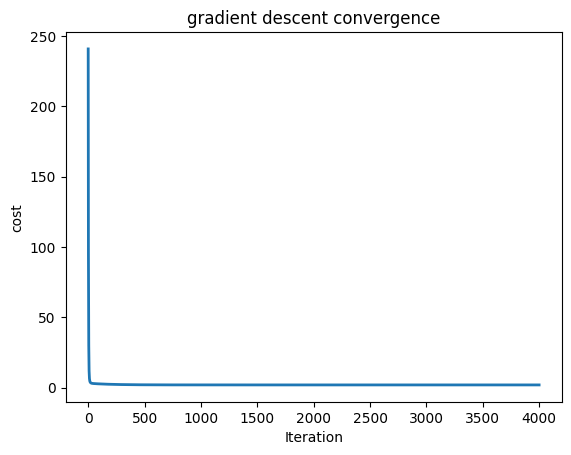

In [11]:
plt.plot(J_history,linewidth=2)
plt.title('gradient descent convergence')
plt.xlabel('Iteration')
plt.ylabel('cost')
plt.show()

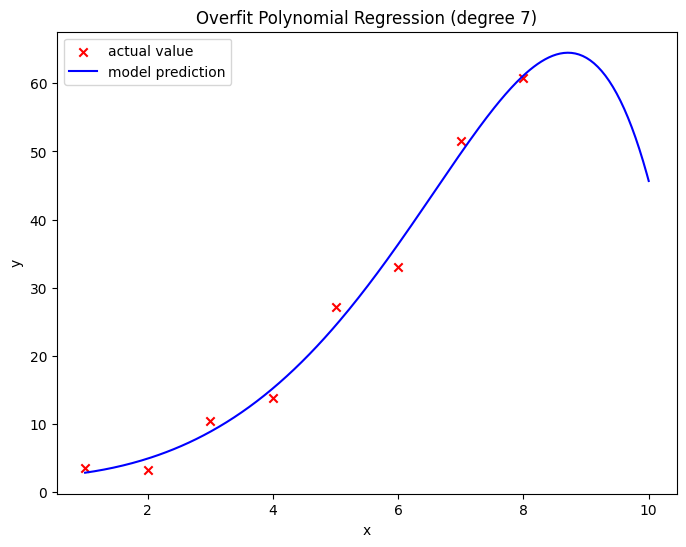

In [12]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, marker='x', c='r', label='actual value')
X_fn,mu,sigma=normalize(X_f)

x_plot = np.linspace(1, 10, 300).reshape(-1, 1)
x_plot_f = np.hstack([x_plot**d for d in range(1, 8)])

x_plot_f = (x_plot_f - mu) / sigma   # use SAME mu, sigma as training

y_plot = x_plot_f @ w + b

plt.plot(x_plot.flatten(), y_plot.flatten(), color='blue', label='model prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Overfit Polynomial Regression (degree 7)')
plt.legend()
plt.show()


In [21]:
def compute_cost_reg(X,y,w,b,lambda_=1):
    m,n=X.shape
    cost=compute_cost(X,y,w,b)

    reg_c=0
    for j in range(n):
        reg_c=reg_c+w[j]**2
    reg_c=reg_c*(lambda_/(2*m))

    total_cost=cost+reg_c
    return total_cost
    

In [22]:
def compute_gradient_reg(X,y,w,b,lambda_=1):
    dj_db,dj_dw=compute_gradient(X,y,w,b)

    m,n=X.shape

    for j in range(n):
        dj_dw[j]+=w[j]*(lambda_/(m))

    return dj_db,dj_dw

In [23]:
w_in=np.zeros(X_f.shape[1])

b_in=0
X_fn=normalize(X_f)[0]
alpha=0.2
iterations=400
J_history,w,b=gradient_descent(X_fn,y,w_in,b_in,compute_cost_reg,compute_gradient_reg,alpha,iterations)
print(f'Paramters:w:{w},b:{b}')

Iteration    0 cost:  247.15
Iteration   40 cost:    9.42
Iteration   80 cost:    9.41
Iteration  120 cost:    9.40
Iteration  160 cost:    9.40
Iteration  200 cost:    9.40
Iteration  240 cost:    9.40
Iteration  280 cost:    9.40
Iteration  320 cost:    9.40
Iteration  360 cost:    9.40
Paramters:w:[ 5.88074168  5.34124144  4.14982428  2.84504086  1.62728839  0.54987913
 -0.38530053],b:25.462499999999995


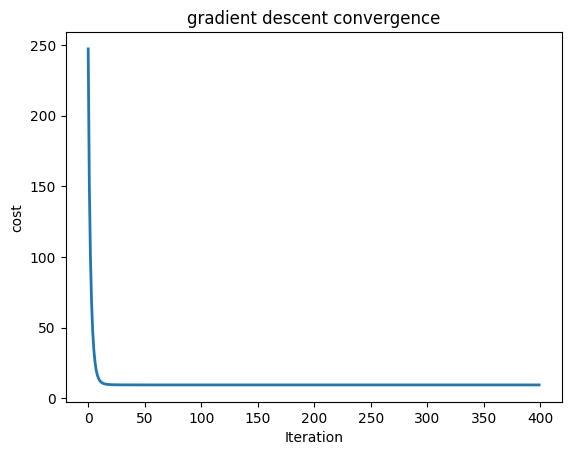

In [24]:
plt.plot(J_history,linewidth=2)
plt.title('gradient descent convergence')
plt.xlabel('Iteration')
plt.ylabel('cost')
plt.show()

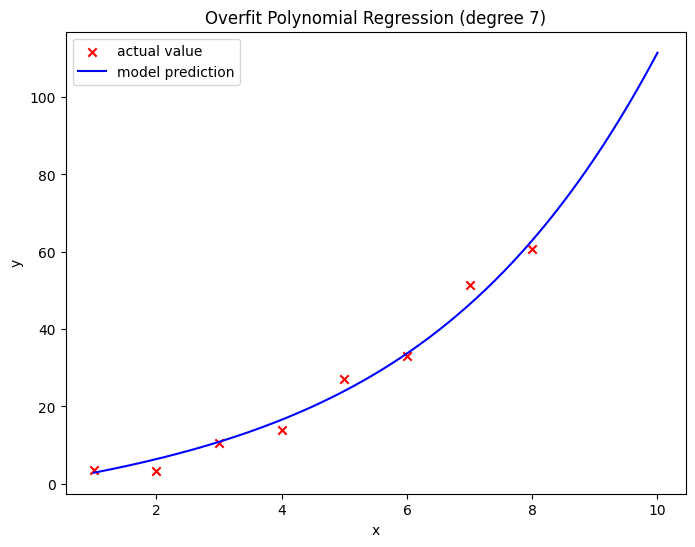

In [25]:
plt.figure(figsize=(8,6))
plt.scatter(X, y, marker='x', c='r', label='actual value')
X_fn,mu,sigma=normalize(X_f)

x_plot = np.linspace(1, 10, 300).reshape(-1, 1)
x_plot_f = np.hstack([x_plot**d for d in range(1, 8)])

x_plot_f = (x_plot_f - mu) / sigma   # use SAME mu, sigma as training

y_plot = x_plot_f @ w + b

plt.plot(x_plot.flatten(), y_plot.flatten(), color='blue', label='model prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Overfit Polynomial Regression (degree 7)')
plt.legend()
plt.show()
